# Shared candidate-action zero-shot transfer: action-space study

This notebook analyzes the deterministic **50-episode WCCI test-set**
evaluations of the bus14-trained shared candidate-action models. It
compares:

- nominal action-space caps `64`, `128`, `256`, `512`, and `1024`;
- `NL` (unscaled) against `NLS` (physically scaled inputs);
- joint mean against typed mean pooling;
- candidate features off/on (`f0`/`f1`);
- a separate do-nothing head off/on (`a0h0`/`a0h1`);
- performance on chronics where **do-nothing reaches 100% survival**
  versus chronics where it fails before the horizon.

The main metric is mean normalized episode length, expressed as a
survival percentage. Every comparison is descriptive: all models use
seed 0 / one selected checkpoint, so chronic-level uncertainty does
not replace replication over training seeds.


In [1]:
from pathlib import Path
from itertools import product
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", context="notebook")


def find_task_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        direct = candidate if candidate.name == "Topology_Task" else candidate / "Topology_Task"
        if (direct / "main.py").is_file():
            return direct
    raise FileNotFoundError("Could not locate the Topology_Task directory")


TASK_DIR = find_task_dir()
RESULT_ROOT = TASK_DIR / "outputs" / "full_test_eval" / "shared"
DO_NOTHING_PATH = (
    TASK_DIR / "outputs" / "do_nothing_eval" / "wcci_test_nomaint_50"
    / "do_nothing_summary.json"
)
ACTION_METADATA_DIR = (
    TASK_DIR / "outputs" / "teacher_student_datasets"
    / "wcci_full2048a_90_v3" / "metadata"
)
EXPORT_DIR = TASK_DIR / "outputs" / "analysis" / "shared_zero_shot_action_space"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ACTION_ORDER = [64, 128, 256, 512, 1024]
FAMILY_ORDER = ["NL", "NLS"]
FAMILY_COLORS = {"NL": "#4C78A8", "NLS": "#F58518"}
COHORT_ORDER = ["Do-nothing < 100%", "Do-nothing = 100%"]
COHORT_COLORS = {
    "Do-nothing < 100%": "#D95F02",
    "Do-nothing = 100%": "#1B9E77",
}
RNG_SEED = 20260816


def save_figure(fig, stem):
    path = EXPORT_DIR / f"{stem}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    return path


print("Task directory:", TASK_DIR)
print("Evaluation directory:", RESULT_ROOT)
print("Exports:", EXPORT_DIR)


Task directory: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task
Evaluation directory: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/full_test_eval/shared
Exports: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/shared_zero_shot_action_space


## 1. Load the 80 evaluations and their 4,000 episode rows

The parser selects only WCCI transfer directories. The older directory
without an `_mk...` suffix is the 256-action campaign. Episode files
are resolved from each result JSON's `action_artifacts` field, avoiding
filename guesses.


In [2]:
MODEL_RE = re.compile(
    r"_shared_(?P<pool>mean|tmean)_f(?P<features>[01])_a0h(?P<head>[01])_s(?P<seed>\d+)"
)
ACTION_RE = re.compile(r"_mk(?P<size>\d+)$")


def load_json(path):
    with Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)


def task_relative(path_string):
    path = Path(path_string)
    if path.is_absolute() and path.is_file():
        return path
    if path.parts and path.parts[0] == "outputs":
        return TASK_DIR / path
    if path.is_file():
        return path.resolve()
    return TASK_DIR / path


def model_label(family, pool, features, head):
    pool_label = "typed mean" if pool == "tmean" else "mean"
    return f"{family} · {pool_label} · f{features} · a0h{head}"


run_rows = []
episode_frames = []

for result_path in sorted(RESULT_ROOT.rglob("*.json")):
    directory = result_path.parent.name
    if "_wcci36" not in directory:
        continue
    if directory.startswith("NLS_"):
        family = "NLS"
    elif directory.startswith("NL_"):
        family = "NL"
    else:
        continue

    action_match = ACTION_RE.search(directory)
    action_size = int(action_match.group("size")) if action_match else 256
    payload = load_json(result_path)
    checkpoint_stem = Path(payload["checkpoint"]).stem
    model_match = MODEL_RE.search(checkpoint_stem)
    if model_match is None:
        raise ValueError(f"Could not parse model factors from {checkpoint_stem}")

    pool = model_match.group("pool")
    features = int(model_match.group("features"))
    head = int(model_match.group("head"))
    seed = int(model_match.group("seed"))
    run_id = f"{family}_mk{action_size}_{pool}_f{features}_a0h{head}_s{seed}"
    episode_path = task_relative(
        payload["action_artifacts"]["episode_summary_csv"]
    )
    if not episode_path.is_file():
        raise FileNotFoundError(
            f"Missing episode summary referenced by {result_path}: {episode_path}"
        )

    episodes = pd.read_csv(episode_path)
    policy_count_columns = [
        column for column in episodes.columns
        if column.startswith("policy_nonidle_count_agent_")
    ]
    if not policy_count_columns:
        raise ValueError(f"No policy non-idle counts in {episode_path}")
    episodes["policy_intervention_rate"] = (
        episodes[policy_count_columns].sum(axis=1)
        / (episodes["steps"] * len(policy_count_columns))
    )
    episodes["run_id"] = run_id
    episodes["family"] = family
    episodes["scaled"] = family == "NLS"
    episodes["action_size"] = action_size
    episodes["pool"] = pool
    episodes["features"] = features
    episodes["head"] = head
    episodes["seed"] = seed
    episodes["model_label"] = model_label(family, pool, features, head)
    episode_frames.append(episodes)

    run_rows.append({
        "run_id": run_id,
        "family": family,
        "scaled": family == "NLS",
        "action_size": action_size,
        "pool": pool,
        "features": features,
        "head": head,
        "seed": seed,
        "model_label": model_label(family, pool, features, head),
        "survival_percent": float(payload["survival_percent"]),
        "survival_frac": float(payload["survival_frac"]),
        "checkpoint_global_step": payload.get("checkpoint_global_step"),
        "source_env_id": payload.get("source_env_id"),
        "target_env_id": payload.get("target_env_id"),
        "split": payload.get("split"),
        "eval_episodes": int(payload.get("eval_episodes", -1)),
        "deterministic_eval": bool(payload.get("deterministic_eval")),
        "eval_action_heuristic": payload.get("eval_action_heuristic"),
        "target_reduced_action_space": payload.get("target_reduced_action_space"),
        "checkpoint": payload.get("checkpoint"),
        "result_json": str(result_path),
        "episode_summary_csv": str(episode_path),
    })

run_summary = pd.DataFrame(run_rows).sort_values(
    ["action_size", "family", "pool", "features", "head"]
).reset_index(drop=True)
episode_data = pd.concat(episode_frames, ignore_index=True)

print(f"Loaded {len(run_summary)} evaluations and {len(episode_data):,} episode rows.")


Loaded 80 evaluations and 4,000 episode rows.


In [3]:
expected_configs = set(product(FAMILY_ORDER, ACTION_ORDER, ["mean", "tmean"], [0, 1], [0, 1]))
observed_configs = set(
    run_summary[["family", "action_size", "pool", "features", "head"]]
    .itertuples(index=False, name=None)
)
assert observed_configs == expected_configs, (
    f"Coverage mismatch: missing={sorted(expected_configs - observed_configs)}, "
    f"extra={sorted(observed_configs - expected_configs)}"
)
assert run_summary["run_id"].is_unique
assert set(run_summary["eval_episodes"]) == {50}
assert set(run_summary["target_env_id"]) == {"bus36_wcci_nomaint"}
assert set(run_summary["split"]) == {"test"}
assert set(run_summary["deterministic_eval"]) == {True}
assert set(run_summary["eval_action_heuristic"]) == {"none"}
assert set(episode_data.groupby("run_id").size()) == {50}

episode_means = episode_data.groupby("run_id")["survival"].mean().mul(100)
aggregate_check = run_summary.set_index("run_id")["survival_percent"] - episode_means
assert aggregate_check.abs().max() < 1e-8

chronic_sets = episode_data.groupby("run_id")["chronic_fingerprint"].agg(frozenset)
assert chronic_sets.map(len).eq(50).all()
assert len(set(chronic_sets)) == 1

coverage = (
    run_summary.groupby(["action_size", "family"])
    .agg(evaluations=("run_id", "size"), episodes=("eval_episodes", "sum"))
    .unstack("family")
)
display(coverage)
print("Validation passed: full 5 × 2 × 2 × 2 × 2 factorial coverage.")


evaluations     episodes     
family               NL NLS       NL  NLS
action_size                              
64                    8   8      400  400
128                   8   8      400  400
256                   8   8      400  400
512                   8   8      400  400
1024                  8   8      400  400

Validation passed: full 5 × 2 × 2 × 2 × 2 factorial coverage.


### Effective per-agent action counts

The nominal cap is not always the actual size: agents 0 and 2 exhaust
their complete candidate sets at 77 and 127 actions. Counts below are
read from each metadata JSON's `agents.*.selected_action_size` field,
which is authoritative even if a legacy top-level cap field is stale.


In [4]:
action_space_rows = []
for nominal_size in ACTION_ORDER:
    metadata_path = (
        ACTION_METADATA_DIR
        / f"reduced_action_space_wcci_full2048a_90_v3_mk{nominal_size}.json"
    )
    metadata = load_json(metadata_path)
    selected = {
        agent: int(values["selected_action_size"])
        for agent, values in metadata["agents"].items()
    }
    original = {
        agent: int(values["original_action_size"])
        for agent, values in metadata["agents"].items()
    }
    row = {
        "action_size": nominal_size,
        **{f"{agent}_actions": selected[agent] for agent in sorted(selected)},
        "total_selected": sum(selected.values()),
        "total_original": sum(original.values()),
        "selected_fraction": sum(selected.values()) / sum(original.values()),
        "metadata_path": str(metadata_path),
    }
    action_space_rows.append(row)

action_space_catalog = pd.DataFrame(action_space_rows).sort_values("action_size")
display(
    action_space_catalog.drop(columns=["metadata_path"]).style.format(
        {"selected_fraction": "{:.3%}"}
    )
)


,action_size,agent_0_actions,agent_1_actions,agent_2_actions,agent_3_actions,total_selected,total_original,selected_fraction
0,64,64,64,64,64,256,66965,0.382%
1,128,77,128,127,128,460,66965,0.687%
2,256,77,256,127,256,716,66965,1.069%
3,512,77,512,127,512,1228,66965,1.834%
4,1024,77,1024,127,1024,2252,66965,3.363%


## 2. Match every model episode to the do-nothing baseline

Chronics are joined by `chronic_fingerprint`. The requested split is:

- **Do-nothing = 100%**: the baseline reaches the full horizon;
- **Do-nothing < 100%**: the baseline fails before the horizon.

This distinction prevents a high aggregate score from hiding either
damage to already-safe chronics or improvements on difficult chronics.


In [5]:
do_nothing_payload = load_json(DO_NOTHING_PATH)
do_nothing = pd.DataFrame(do_nothing_payload["episodes"]).copy()
do_nothing = do_nothing.rename(columns={
    "survival": "do_nothing_survival",
    "steps": "do_nothing_steps",
    "full_survival": "do_nothing_full_survival",
})
assert len(do_nothing) == 50
assert do_nothing["chronic_fingerprint"].is_unique

baseline_columns = [
    "chronic_fingerprint", "chronic_name", "do_nothing_survival",
    "do_nothing_steps", "do_nothing_full_survival"
]
episode_analysis = episode_data.merge(
    do_nothing[baseline_columns],
    on="chronic_fingerprint",
    how="left",
    validate="many_to_one",
    suffixes=("", "_baseline"),
)
assert episode_analysis["do_nothing_survival"].notna().all()
assert set(episode_analysis["chronic_fingerprint"]) == set(do_nothing["chronic_fingerprint"])

episode_analysis["cohort"] = np.where(
    episode_analysis["do_nothing_full_survival"],
    "Do-nothing = 100%",
    "Do-nothing < 100%",
)
episode_analysis["model_full_survival"] = episode_analysis["survival"].ge(1 - 1e-12)
episode_analysis["delta_vs_do_nothing_pp"] = (
    episode_analysis["survival"] - episode_analysis["do_nothing_survival"]
) * 100
episode_analysis["improved_vs_do_nothing"] = episode_analysis["delta_vs_do_nothing_pp"].gt(1e-10)
episode_analysis["worse_than_do_nothing"] = episode_analysis["delta_vs_do_nothing_pp"].lt(-1e-10)

do_nothing_overall_percent = do_nothing["do_nothing_survival"].mean() * 100
do_nothing_cohorts = (
    do_nothing.groupby("do_nothing_full_survival")["do_nothing_survival"]
    .agg(["count", "mean", "median", "min", "max"])
    .rename(index={False: "Do-nothing < 100%", True: "Do-nothing = 100%"})
)
do_nothing_cohorts[["mean", "median", "min", "max"]] *= 100
display(do_nothing_cohorts.style.format("{:.2f}"))
print(f"Do-nothing overall mean survival: {do_nothing_overall_percent:.2f}%")


,count,mean,median,min,max
do_nothing_full_survival,,,,,
Do-nothing < 100%,24.00,8.34,5.99,1.23,16.16
Do-nothing = 100%,26.00,100.00,100.00,100.00,100.00


Do-nothing overall mean survival: 56.00%


## 3. Overall model ranking

`full_survival_rate` is the fraction of the 50 chronics that reach the
full horizon. `policy_intervention_percent` is the decision-weighted
fraction of agent outputs that are non-idle.


In [6]:
RUN_KEYS = [
    "run_id", "family", "action_size", "pool", "features", "head",
    "seed", "model_label"
]
ranking = (
    episode_analysis.groupby(RUN_KEYS, as_index=False)
    .agg(
        mean_survival_percent=("survival", lambda values: values.mean() * 100),
        median_survival_percent=("survival", lambda values: values.median() * 100),
        full_survival_rate=("model_full_survival", "mean"),
        episodes=("episode", "size"),
    )
)
weighted_intervention = (
    episode_analysis.assign(
        weighted_interventions=lambda frame: frame["policy_intervention_rate"] * frame["steps"]
    )
    .groupby("run_id")
    .apply(
        lambda frame: frame["weighted_interventions"].sum() / frame["steps"].sum(),
        include_groups=False,
    )
    .rename("policy_intervention_rate")
)
ranking = ranking.merge(weighted_intervention, on="run_id", validate="one_to_one")
ranking["policy_intervention_percent"] = ranking["policy_intervention_rate"] * 100
ranking["delta_vs_do_nothing_pp"] = (
    ranking["mean_survival_percent"] - do_nothing_overall_percent
)
ranking["overall_rank"] = ranking["mean_survival_percent"].rank(
    method="min", ascending=False
).astype(int)
ranking = ranking.sort_values(
    ["mean_survival_percent", "full_survival_rate"], ascending=False
).reset_index(drop=True)

top_columns = [
    "overall_rank", "model_label", "action_size", "mean_survival_percent",
    "median_survival_percent", "full_survival_rate",
    "delta_vs_do_nothing_pp", "policy_intervention_percent"
]
display(
    ranking.head(15)[top_columns].style.format({
        "mean_survival_percent": "{:.2f}%",
        "median_survival_percent": "{:.2f}%",
        "full_survival_rate": "{:.1%}",
        "delta_vs_do_nothing_pp": "{:+.2f} pp",
        "policy_intervention_percent": "{:.2f}%",
    })
)


,overall_rank,model_label,action_size,mean_survival_percent,median_survival_percent,full_survival_rate,delta_vs_do_nothing_pp,policy_intervention_percent
0,1,NLS · typed mean · f0 · a0h0,256,59.75%,100.00%,56.0%,+3.75 pp,24.41%
1,2,NLS · typed mean · f0 · a0h0,128,58.98%,100.00%,56.0%,+2.97 pp,21.66%
2,3,NLS · mean · f1 · a0h0,128,58.47%,100.00%,52.0%,+2.47 pp,52.13%
3,4,NL · typed mean · f0 · a0h0,64,58.00%,100.00%,52.0%,+2.00 pp,2.53%
4,5,NLS · mean · f1 · a0h0,64,57.77%,82.28%,48.0%,+1.77 pp,50.76%
5,6,NL · typed mean · f0 · a0h1,128,57.70%,100.00%,52.0%,+1.70 pp,2.83%
6,7,NLS · typed mean · f0 · a0h0,64,57.69%,100.00%,52.0%,+1.68 pp,0.10%
7,8,NLS · mean · f1 · a0h0,256,57.66%,95.88%,50.0%,+1.66 pp,52.49%
8,9,NLS · mean · f1 · a0h0,512,56.49%,74.93%,46.0%,+0.49 pp,51.45%
9,10,NL · typed mean · f0 · a0h1,64,56.42%,95.08%,48.0%,+0.42 pp,1.03%


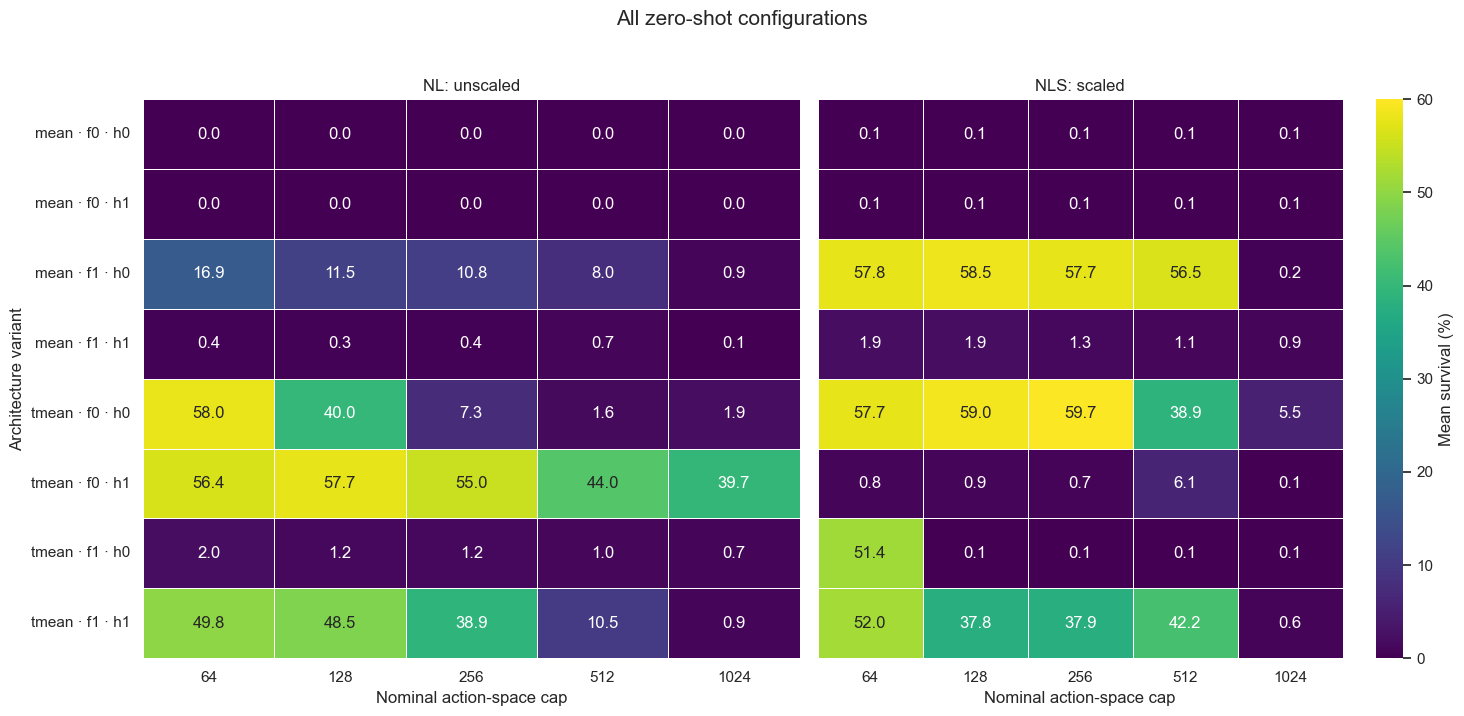

In [7]:
variant_order = [
    f"{pool} · f{features} · h{head}"
    for pool in ["mean", "tmean"]
    for features in [0, 1]
    for head in [0, 1]
]
heatmap_data = ranking.copy()
heatmap_data["variant"] = (
    heatmap_data["pool"] + " · f" + heatmap_data["features"].astype(str)
    + " · h" + heatmap_data["head"].astype(str)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
for axis, family in zip(axes, FAMILY_ORDER):
    matrix = (
        heatmap_data.loc[heatmap_data["family"].eq(family)]
        .pivot(index="variant", columns="action_size", values="mean_survival_percent")
        .reindex(index=variant_order, columns=ACTION_ORDER)
    )
    sns.heatmap(
        matrix, annot=True, fmt=".1f", cmap="viridis", vmin=0, vmax=60,
        linewidths=0.5, cbar=axis is axes[-1], ax=axis,
        cbar_kws={"label": "Mean survival (%)"},
    )
    axis.set_title(f"{family}: {'scaled' if family == 'NLS' else 'unscaled'}")
    axis.set_xlabel("Nominal action-space cap")
    axis.set_ylabel("Architecture variant" if axis is axes[0] else "")
fig.suptitle("All zero-shot configurations", y=1.02, fontsize=15)
fig.tight_layout()
save_figure(fig, "all_configurations_heatmap")
plt.show()


## 4. Which action-space size performs best?

Two answers are reported deliberately:

1. **robust across architectures** — mean/median across the 16 matched
   model variants and how often a size wins within a variant;
2. **best achievable result** — the best single model at each size.

This avoids selecting a cap from one unusually favorable interaction.


In [8]:
CONFIG_KEYS = ["family", "pool", "features", "head"]
config_by_size = ranking.pivot(
    index=CONFIG_KEYS, columns="action_size", values="mean_survival_percent"
).reindex(columns=ACTION_ORDER)
winning_size = config_by_size.idxmax(axis=1)

action_space_summary = (
    ranking.groupby("action_size")["mean_survival_percent"]
    .agg(across_model_mean="mean", across_model_median="median", best_single="max", worst_single="min")
    .reindex(ACTION_ORDER)
    .reset_index()
)
action_space_summary["config_wins"] = (
    winning_size.value_counts().reindex(ACTION_ORDER, fill_value=0).to_numpy()
)
action_space_summary["config_win_rate"] = action_space_summary["config_wins"] / len(config_by_size)
best_at_size = (
    ranking.sort_values("mean_survival_percent", ascending=False)
    .drop_duplicates("action_size")
    .set_index("action_size")
)
action_space_summary["best_model"] = action_space_summary["action_size"].map(
    best_at_size["model_label"]
)
action_space_summary = action_space_summary.merge(
    action_space_catalog.drop(columns=["metadata_path"]),
    on="action_size", how="left", validate="one_to_one"
)
display(
    action_space_summary[[
        "action_size", "agent_0_actions", "agent_1_actions", "agent_2_actions",
        "agent_3_actions", "total_selected", "across_model_mean",
        "across_model_median", "best_single", "config_wins",
        "config_win_rate", "best_model"
    ]].style.format({
        "across_model_mean": "{:.2f}%",
        "across_model_median": "{:.2f}%",
        "best_single": "{:.2f}%",
        "config_win_rate": "{:.1%}",
    })
)

vs_64_rows = []
for size in ACTION_ORDER[1:]:
    differences = config_by_size[size] - config_by_size[64]
    vs_64_rows.append({
        "action_size": size,
        "mean_delta_vs_64_pp": differences.mean(),
        "median_delta_vs_64_pp": differences.median(),
        "win_rate_vs_64": differences.gt(0).mean(),
    })
action_size_vs_64 = pd.DataFrame(vs_64_rows)
display(action_size_vs_64.style.format({
    "mean_delta_vs_64_pp": "{:+.2f} pp",
    "median_delta_vs_64_pp": "{:+.2f} pp",
    "win_rate_vs_64": "{:.1%}",
}))


,action_size,agent_0_actions,agent_1_actions,agent_2_actions,agent_3_actions,total_selected,across_model_mean,across_model_median,best_single,config_wins,config_win_rate,best_model
0,64,64,64,64,64,256,25.33%,9.46%,58.00%,9,56.2%,NL · typed mean · f0 · a0h0
1,128,77,128,127,128,460,19.85%,1.56%,58.98%,3,18.8%,NLS · typed mean · f0 · a0h0
2,256,77,256,127,256,716,16.95%,1.24%,59.75%,1,6.2%,NLS · typed mean · f0 · a0h0
3,512,77,512,127,512,1228,13.17%,1.33%,56.49%,3,18.8%,NLS · mean · f1 · a0h0
4,1024,77,1024,127,1024,2252,3.24%,0.40%,39.75%,0,0.0%,NL · typed mean · f0 · a0h1


,action_size,mean_delta_vs_64_pp,median_delta_vs_64_pp,win_rate_vs_64
0,128,-5.48 pp,+0.00 pp,37.5%
1,256,-8.38 pp,-0.39 pp,12.5%
2,512,-12.15 pp,-1.16 pp,18.8%
3,1024,-22.09 pp,-8.66 pp,6.2%


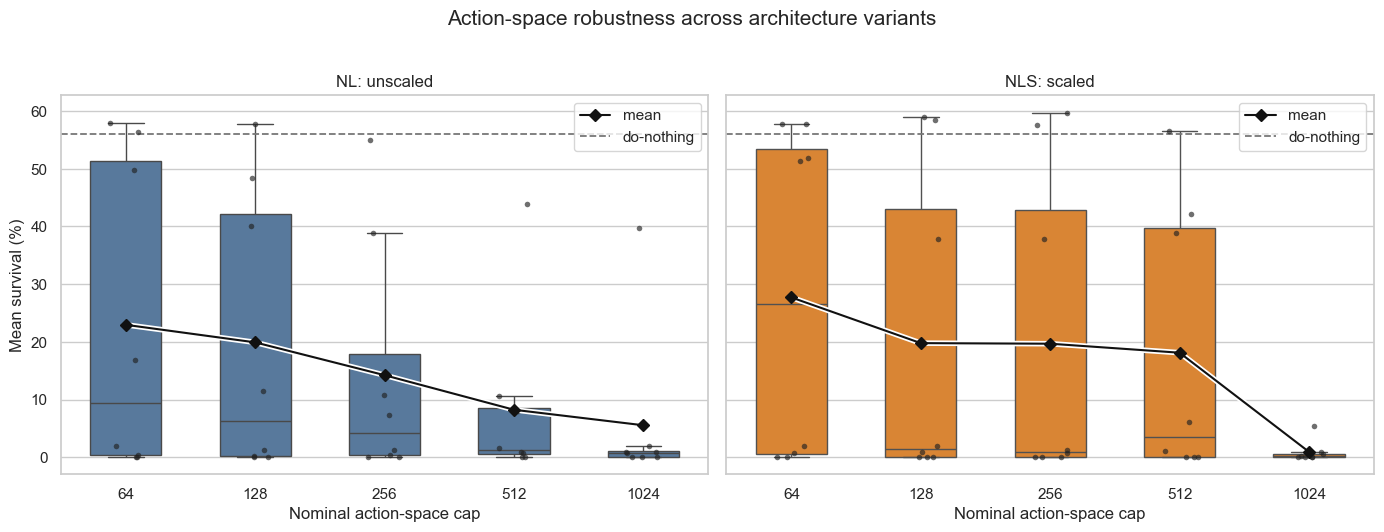

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for axis, family in zip(axes, FAMILY_ORDER):
    subset = ranking.loc[ranking["family"].eq(family)]
    sns.boxplot(
        data=subset, x="action_size", y="mean_survival_percent",
        order=ACTION_ORDER, color=FAMILY_COLORS[family], width=0.55,
        showfliers=False, ax=axis,
    )
    sns.stripplot(
        data=subset, x="action_size", y="mean_survival_percent",
        order=ACTION_ORDER, color="#222222", alpha=0.65, size=4, jitter=0.14,
        ax=axis,
    )
    family_means = subset.groupby("action_size")["mean_survival_percent"].mean().reindex(ACTION_ORDER)
    axis.plot(range(len(ACTION_ORDER)), family_means, color="white", linewidth=4, zorder=4)
    axis.plot(range(len(ACTION_ORDER)), family_means, color="#111111", marker="D", linewidth=1.5, zorder=5, label="mean")
    axis.axhline(do_nothing_overall_percent, color="#777777", linestyle="--", linewidth=1.3, label="do-nothing")
    axis.set_title(f"{family}: {'scaled' if family == 'NLS' else 'unscaled'}")
    axis.set_xlabel("Nominal action-space cap")
    axis.set_ylabel("Mean survival (%)" if axis is axes[0] else "")
    axis.legend(loc="upper right")
fig.suptitle("Action-space robustness across architecture variants", y=1.02, fontsize=15)
fig.tight_layout()
save_figure(fig, "action_space_distributions")
plt.show()


## 5. Scaled versus unscaled and architecture-factor effects

Every effect below is matched: all other factors, including action
size, are held fixed. A positive value favors the named treatment.
These are descriptive contrasts over model cells, not independent
training-seed estimates. The bootstrap intervals resample matched
cells and therefore only summarize dispersion across this factorial
table.


In [10]:
def matched_effects(name, index_columns, factor_column, treatment, reference):
    pivot = ranking.pivot(
        index=index_columns,
        columns=factor_column,
        values="mean_survival_percent",
    ).dropna(subset=[treatment, reference])
    result = pivot.reset_index()
    result["factor"] = name
    result["treatment"] = str(treatment)
    result["reference"] = str(reference)
    result["effect_pp"] = result[treatment] - result[reference]
    return result


effect_frames = [
    matched_effects(
        "Physical scaling (NLS − NL)",
        ["action_size", "pool", "features", "head"],
        "family", "NLS", "NL",
    ),
    matched_effects(
        "Typed mean (tmean − mean)",
        ["family", "action_size", "features", "head"],
        "pool", "tmean", "mean",
    ),
    matched_effects(
        "Candidate features (f1 − f0)",
        ["family", "action_size", "pool", "head"],
        "features", 1, 0,
    ),
    matched_effects(
        "Separate do-nothing head (h1 − h0)",
        ["family", "action_size", "pool", "features"],
        "head", 1, 0,
    ),
]
matched_factor_effects = pd.concat(effect_frames, ignore_index=True, sort=False)


def bootstrap_mean_ci(values, draws=20_000, seed=RNG_SEED):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    samples = rng.choice(values, size=(draws, len(values)), replace=True).mean(axis=1)
    return np.quantile(samples, [0.025, 0.975])


factor_rows = []
for offset, (factor, values) in enumerate(
    matched_factor_effects.groupby("factor", sort=False)["effect_pp"]
):
    low, high = bootstrap_mean_ci(values, seed=RNG_SEED + offset)
    factor_rows.append({
        "factor": factor,
        "pairs": len(values),
        "mean_effect_pp": values.mean(),
        "median_effect_pp": values.median(),
        "win_rate": values.gt(0).mean(),
        "ci_low_pp": low,
        "ci_high_pp": high,
        "min_effect_pp": values.min(),
        "max_effect_pp": values.max(),
    })
factor_effect_summary = pd.DataFrame(factor_rows)
display(factor_effect_summary.style.format({
    "mean_effect_pp": "{:+.2f}",
    "median_effect_pp": "{:+.2f}",
    "win_rate": "{:.1%}",
    "ci_low_pp": "{:+.2f}",
    "ci_high_pp": "{:+.2f}",
    "min_effect_pp": "{:+.2f}",
    "max_effect_pp": "{:+.2f}",
}))


,factor,pairs,mean_effect_pp,median_effect_pp,win_rate,ci_low_pp,ci_high_pp,min_effect_pp,max_effect_pp
0,Physical scaling (NLS − NL),40,+3.07,+0.02,65.0%,-5.17,+11.19,-56.82,+52.43
1,Typed mean (tmean − mean),40,+16.97,+6.64,72.5%,+6.74,+26.89,-58.38,+59.70
2,Candidate features (f1 − f0),40,+1.81,+0.43,62.5%,-7.42,+11.30,-59.69,+58.42
3,Separate do-nothing head (h1 − h0),40,-1.92,+0.01,50.0%,-11.97,+7.86,-59.07,+47.74


action_size,64,128,256,512,1024
factor,,,,,
Candidate features (f1 − f0),+7.38 pp,+0.24 pp,+3.17 pp,+3.68 pp,-5.39 pp
Physical scaling (NLS − NL),+4.75 pp,-0.13 pp,+5.46 pp,+9.89 pp,-4.61 pp
Separate do-nothing head (h1 − h0),-10.31 pp,-2.90 pp,-0.33 pp,-0.16 pp,+4.12 pp
Typed mean (tmean − mean),+31.34 pp,+21.59 pp,+16.31 pp,+9.72 pp,+5.90 pp


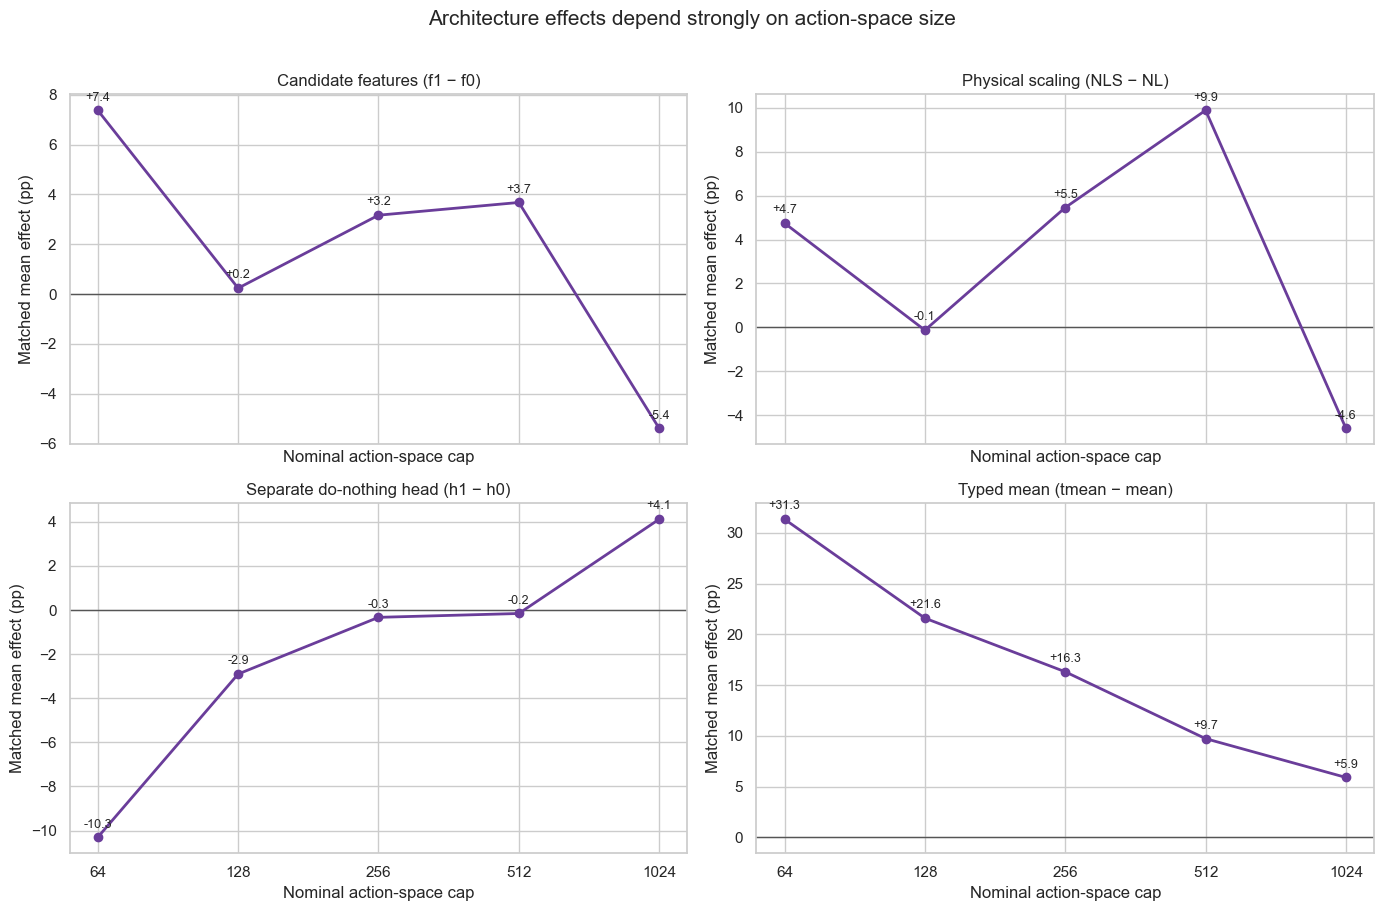

In [11]:
factor_effect_by_size = (
    matched_factor_effects.groupby(["factor", "action_size"])["effect_pp"]
    .agg(mean_effect_pp="mean", median_effect_pp="median", win_rate=lambda values: values.gt(0).mean(), pairs="size")
    .reset_index()
)
display(
    factor_effect_by_size.pivot(
        index="factor", columns="action_size", values="mean_effect_pp"
    ).reindex(columns=ACTION_ORDER).style.format("{:+.2f} pp")
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for axis, (factor, subset) in zip(
    axes.flat, factor_effect_by_size.groupby("factor", sort=False)
):
    subset = subset.set_index("action_size").reindex(ACTION_ORDER).reset_index()
    axis.axhline(0, color="#555555", linewidth=1)
    axis.plot(
        subset["action_size"].astype(str), subset["mean_effect_pp"],
        color="#6A3D9A", marker="o", linewidth=2,
    )
    for _, row in subset.iterrows():
        axis.annotate(
            f"{row['mean_effect_pp']:+.1f}",
            (str(int(row["action_size"])), row["mean_effect_pp"]),
            xytext=(0, 7), textcoords="offset points", ha="center", fontsize=9,
        )
    axis.set_title(factor)
    axis.set_xlabel("Nominal action-space cap")
    axis.set_ylabel("Matched mean effect (pp)")
fig.suptitle("Architecture effects depend strongly on action-space size", y=1.01, fontsize=15)
fig.tight_layout()
save_figure(fig, "factor_effects_by_action_size")
plt.show()


## 6. Do-nothing-easy versus do-nothing-hard chronics

For each model:

- `easy_mean_survival` and `easy_preservation_rate` measure whether it
  avoids breaking the 26 chronics already solved by do-nothing;
- `hard_mean_survival`, `hard_delta_vs_do_nothing`, and
  `hard_rescue_rate` measure improvement on the 24 chronics where
  do-nothing fails;
- a rescue means the model reaches 100% on a hard chronic.


In [12]:
cohort_summary = (
    episode_analysis.groupby(RUN_KEYS + ["cohort"], as_index=False)
    .agg(
        episodes=("episode", "size"),
        model_mean_survival=("survival", "mean"),
        model_median_survival=("survival", "median"),
        model_full_survival_rate=("model_full_survival", "mean"),
        do_nothing_mean_survival=("do_nothing_survival", "mean"),
        mean_delta_vs_do_nothing_pp=("delta_vs_do_nothing_pp", "mean"),
        intervention_rate=("policy_intervention_rate", "mean"),
        improved_episode_rate=("improved_vs_do_nothing", "mean"),
        worse_episode_rate=("worse_than_do_nothing", "mean"),
    )
)

cohort_wide = cohort_summary.pivot(
    index=RUN_KEYS,
    columns="cohort",
    values=[
        "model_mean_survival", "model_full_survival_rate",
        "mean_delta_vs_do_nothing_pp", "intervention_rate"
    ],
)
cohort_wide.columns = [
    f"{metric}_{'easy' if cohort == 'Do-nothing = 100%' else 'hard'}"
    for metric, cohort in cohort_wide.columns
]
cohort_wide = cohort_wide.reset_index()
cohort_wide = cohort_wide.merge(
    ranking[["run_id", "overall_rank", "mean_survival_percent"]],
    on="run_id", validate="one_to_one"
)
cohort_wide = cohort_wide.rename(columns={
    "model_mean_survival_easy": "easy_mean_survival",
    "model_mean_survival_hard": "hard_mean_survival",
    "model_full_survival_rate_easy": "easy_preservation_rate",
    "model_full_survival_rate_hard": "hard_rescue_rate",
    "mean_delta_vs_do_nothing_pp_easy": "easy_delta_vs_do_nothing_pp",
    "mean_delta_vs_do_nothing_pp_hard": "hard_delta_vs_do_nothing_pp",
    "intervention_rate_easy": "easy_intervention_rate",
    "intervention_rate_hard": "hard_intervention_rate",
})

cohort_display = cohort_wide.sort_values("overall_rank").head(15)[[
    "overall_rank", "model_label", "action_size", "mean_survival_percent",
    "easy_mean_survival", "easy_preservation_rate", "easy_delta_vs_do_nothing_pp",
    "hard_mean_survival", "hard_rescue_rate", "hard_delta_vs_do_nothing_pp"
]]
display(cohort_display.style.format({
    "mean_survival_percent": "{:.2f}%",
    "easy_mean_survival": "{:.2%}",
    "easy_preservation_rate": "{:.1%}",
    "easy_delta_vs_do_nothing_pp": "{:+.2f} pp",
    "hard_mean_survival": "{:.2%}",
    "hard_rescue_rate": "{:.1%}",
    "hard_delta_vs_do_nothing_pp": "{:+.2f} pp",
}))


,overall_rank,model_label,action_size,mean_survival_percent,easy_mean_survival,easy_preservation_rate,easy_delta_vs_do_nothing_pp,hard_mean_survival,hard_rescue_rate,hard_delta_vs_do_nothing_pp
20,1,NLS · typed mean · f0 · a0h0,256,59.75%,98.81%,96.2%,-1.19 pp,17.43%,12.5%,+9.09 pp
12,2,NLS · typed mean · f0 · a0h0,128,58.98%,97.17%,96.2%,-2.83 pp,17.60%,12.5%,+9.26 pp
10,3,NLS · mean · f1 · a0h0,128,58.47%,96.27%,92.3%,-3.73 pp,17.52%,8.3%,+9.18 pp
76,4,NL · typed mean · f0 · a0h0,64,58.00%,99.98%,96.2%,-0.02 pp,12.53%,4.2%,+4.19 pp
34,5,NLS · mean · f1 · a0h0,64,57.77%,95.08%,88.5%,-4.92 pp,17.35%,4.2%,+9.01 pp
53,6,NL · typed mean · f0 · a0h1,128,57.70%,99.98%,96.2%,-0.02 pp,11.89%,4.2%,+3.55 pp
36,7,NLS · typed mean · f0 · a0h0,64,57.69%,99.98%,96.2%,-0.02 pp,11.86%,4.2%,+3.52 pp
18,8,NLS · mean · f1 · a0h0,256,57.66%,96.84%,92.3%,-3.16 pp,15.22%,4.2%,+6.88 pp
26,9,NLS · mean · f1 · a0h0,512,56.49%,94.92%,84.6%,-5.08 pp,14.87%,4.2%,+6.53 pp
77,10,NL · typed mean · f0 · a0h1,64,56.42%,99.62%,92.3%,-0.38 pp,9.63%,0.0%,+1.29 pp


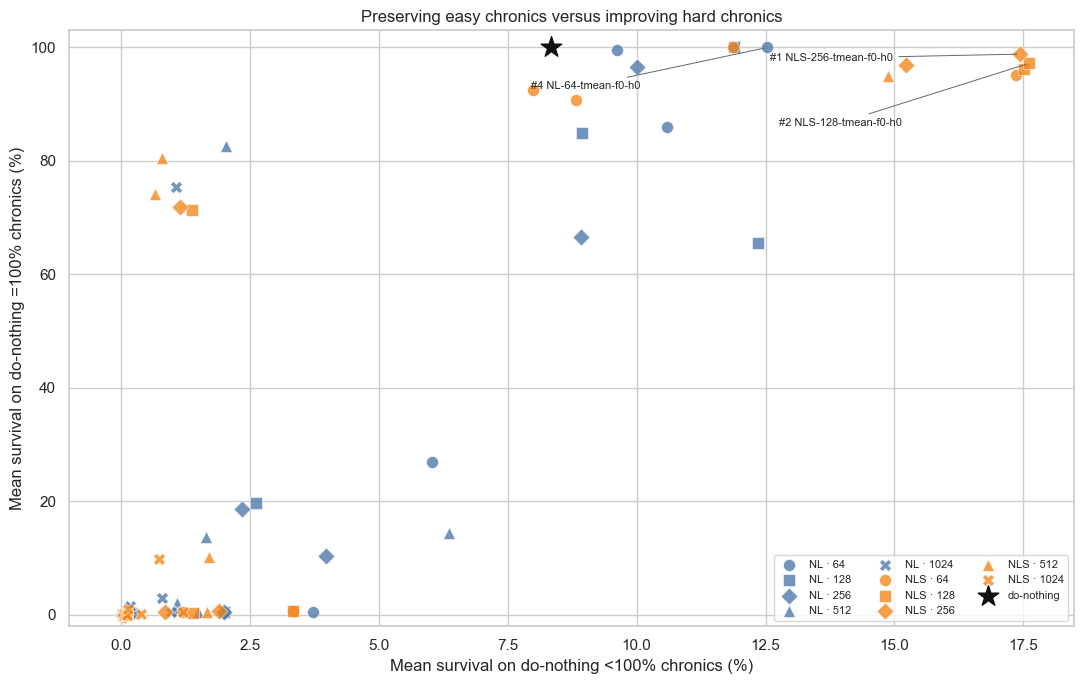

In [13]:
fig, axis = plt.subplots(figsize=(11, 7))
marker_by_size = {64: "o", 128: "s", 256: "D", 512: "^", 1024: "X"}
for (family, size), subset in cohort_wide.groupby(["family", "action_size"]):
    axis.scatter(
        subset["hard_mean_survival"] * 100,
        subset["easy_mean_survival"] * 100,
        color=FAMILY_COLORS[family], marker=marker_by_size[size],
        s=75, alpha=0.78, edgecolor="white", linewidth=0.5,
        label=f"{family} · {size}",
    )
axis.scatter(
    do_nothing_cohorts.loc["Do-nothing < 100%", "mean"], 100,
    marker="*", s=240, color="#111111", label="do-nothing", zorder=6,
)
label_offsets = {1: (-180, -5), 2: (-180, -45), 4: (-170, -30)}
for _, row in cohort_wide.loc[
    cohort_wide["overall_rank"].isin(label_offsets)
].sort_values("overall_rank").iterrows():
    short = f"#{row['overall_rank']} {row['family']}-{row['action_size']}-{row['pool']}-f{row['features']}-h{row['head']}"
    axis.annotate(
        short,
        (row["hard_mean_survival"] * 100, row["easy_mean_survival"] * 100),
        xytext=label_offsets[int(row["overall_rank"])],
        textcoords="offset points", fontsize=8,
        arrowprops={"arrowstyle": "-", "color": "#666666", "linewidth": 0.7},
    )
axis.set_xlabel("Mean survival on do-nothing <100% chronics (%)")
axis.set_ylabel("Mean survival on do-nothing =100% chronics (%)")
axis.set_title("Preserving easy chronics versus improving hard chronics")
axis.set_xlim(left=-1)
axis.set_ylim(bottom=-2, top=103)
axis.legend(ncol=3, fontsize=8, loc="lower right")
fig.tight_layout()
save_figure(fig, "easy_vs_hard_chronics")
plt.show()


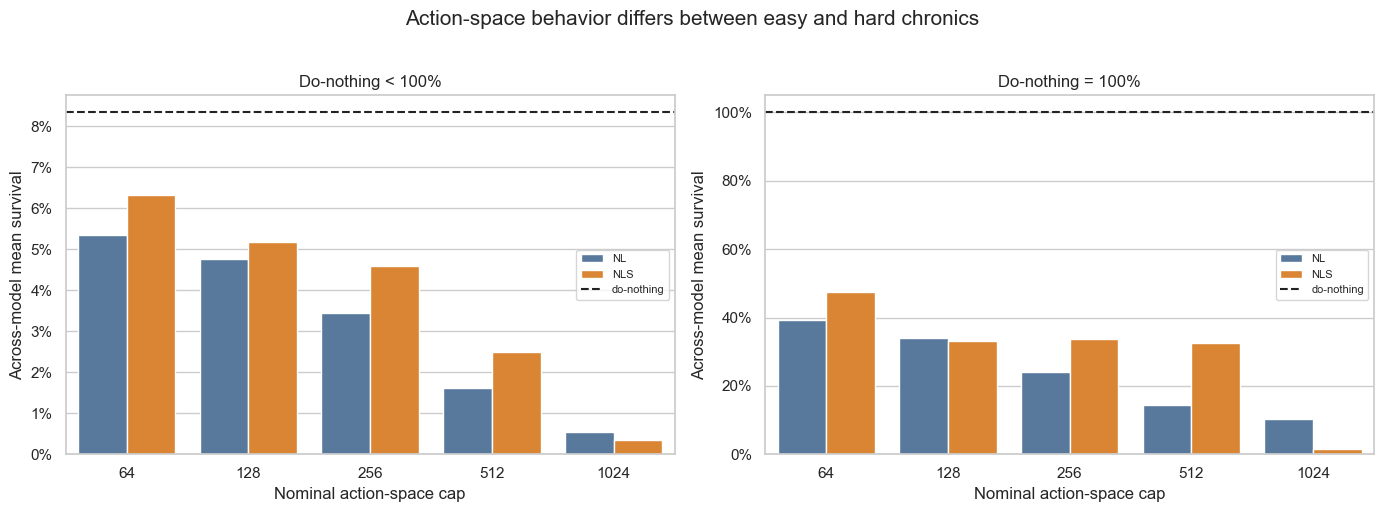

In [14]:
cohort_by_family_size = (
    cohort_summary.groupby(["family", "action_size", "cohort"], as_index=False)
    .agg(
        across_model_mean_survival=("model_mean_survival", "mean"),
        across_model_mean_full_rate=("model_full_survival_rate", "mean"),
        across_model_mean_delta_pp=("mean_delta_vs_do_nothing_pp", "mean"),
    )
)
display(
    cohort_by_family_size.pivot_table(
        index=["family", "action_size"], columns="cohort",
        values="across_model_mean_survival"
    ).reindex(COHORT_ORDER, axis=1).style.format("{:.2%}")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for axis, cohort in zip(axes, COHORT_ORDER):
    subset = cohort_by_family_size.loc[cohort_by_family_size["cohort"].eq(cohort)]
    sns.barplot(
        data=subset, x="action_size", y="across_model_mean_survival",
        hue="family", order=ACTION_ORDER, hue_order=FAMILY_ORDER,
        palette=FAMILY_COLORS, ax=axis,
    )
    baseline_value = (
        do_nothing_cohorts.loc[cohort, "mean"] / 100
    )
    axis.axhline(baseline_value, color="#222222", linestyle="--", label="do-nothing")
    axis.set_title(cohort)
    axis.set_xlabel("Nominal action-space cap")
    axis.set_ylabel("Across-model mean survival")
    axis.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    handles, labels = axis.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axis.legend(by_label.values(), by_label.keys(), fontsize=8)
fig.suptitle("Action-space behavior differs between easy and hard chronics", y=1.02, fontsize=15)
fig.tight_layout()
save_figure(fig, "cohort_action_space_summary")
plt.show()


## 7. Difficult-chronic metric for every model

This ranking uses **only the 24 chronics where do-nothing fails**.
Because a few complete rescues can dominate the mean, the table keeps
several complementary quantities:

- `difficult_mean_survival`: reward for total performance, including
  complete rescues;
- `difficult_median_survival`: performance on a typical difficult
  chronic, resistant to a few 100% outcomes;
- win/loss and rescue rates versus the matched do-nothing episode;
- `nonrescue_delta`: a diagnostic mean difference after removing the
  chronics fully rescued by that model.

The non-rescue column is not a standalone fair ranking because each
model can remove a different set of chronics. It is included to reveal
when a high mean is carried almost entirely by isolated rescues.


In [15]:
difficult_episodes = episode_analysis.loc[
    episode_analysis["cohort"].eq("Do-nothing < 100%")
].copy()
assert difficult_episodes["chronic_fingerprint"].nunique() == 24

difficult_model_metrics = (
    difficult_episodes.groupby(RUN_KEYS, as_index=False)
    .agg(
        difficult_episodes=("episode", "size"),
        difficult_mean_survival_percent=("survival", lambda values: values.mean() * 100),
        difficult_median_survival_percent=("survival", lambda values: values.median() * 100),
        difficult_mean_delta_pp=("delta_vs_do_nothing_pp", "mean"),
        difficult_median_delta_pp=("delta_vs_do_nothing_pp", "median"),
        difficult_win_rate=("improved_vs_do_nothing", "mean"),
        difficult_loss_rate=("worse_than_do_nothing", "mean"),
        difficult_rescue_rate=("model_full_survival", "mean"),
        difficult_rescues=("model_full_survival", "sum"),
    )
)
difficult_model_metrics["difficult_tie_rate"] = (
    1 - difficult_model_metrics["difficult_win_rate"]
    - difficult_model_metrics["difficult_loss_rate"]
)

nonrescue_metrics = (
    difficult_episodes.loc[~difficult_episodes["model_full_survival"]]
    .groupby("run_id", as_index=False)
    .agg(
        difficult_nonrescue_episodes=("episode", "size"),
        difficult_nonrescue_mean_survival_percent=("survival", lambda values: values.mean() * 100),
        difficult_nonrescue_mean_delta_pp=("delta_vs_do_nothing_pp", "mean"),
    )
)
difficult_model_metrics = difficult_model_metrics.merge(
    nonrescue_metrics, on="run_id", how="left", validate="one_to_one"
)
difficult_model_metrics["difficult_mean_rank"] = (
    difficult_model_metrics["difficult_mean_survival_percent"]
    .rank(method="min", ascending=False).astype(int)
)
difficult_model_metrics["difficult_median_rank"] = (
    difficult_model_metrics["difficult_median_survival_percent"]
    .rank(method="min", ascending=False).astype(int)
)
difficult_model_metrics = difficult_model_metrics.sort_values(
    ["difficult_mean_rank", "difficult_median_rank"]
).reset_index(drop=True)

difficult_columns = [
    "difficult_mean_rank", "model_label", "action_size",
    "difficult_mean_survival_percent", "difficult_median_survival_percent",
    "difficult_mean_delta_pp", "difficult_median_delta_pp",
    "difficult_win_rate", "difficult_loss_rate", "difficult_rescues",
    "difficult_rescue_rate", "difficult_nonrescue_mean_delta_pp"
]
display(
    difficult_model_metrics.head(20)[difficult_columns].style.format({
        "difficult_mean_survival_percent": "{:.2f}%",
        "difficult_median_survival_percent": "{:.2f}%",
        "difficult_mean_delta_pp": "{:+.2f} pp",
        "difficult_median_delta_pp": "{:+.2f} pp",
        "difficult_win_rate": "{:.1%}",
        "difficult_loss_rate": "{:.1%}",
        "difficult_rescue_rate": "{:.1%}",
        "difficult_nonrescue_mean_delta_pp": "{:+.2f} pp",
    })
)
print(
    "The table above shows the top 20 by difficult-chronic mean; "
    "difficult_model_metrics contains all 80 models."
)


,difficult_mean_rank,model_label,action_size,difficult_mean_survival_percent,difficult_median_survival_percent,difficult_mean_delta_pp,difficult_median_delta_pp,difficult_win_rate,difficult_loss_rate,difficult_rescues,difficult_rescue_rate,difficult_nonrescue_mean_delta_pp
0,1,NLS · typed mean · f0 · a0h0,128,17.60%,5.30%,+9.26 pp,-0.26 pp,25.0%,54.2%,3,12.5%,-1.90 pp
1,2,NLS · mean · f1 · a0h0,128,17.52%,6.00%,+9.18 pp,-0.00 pp,33.3%,33.3%,2,8.3%,+1.91 pp
2,3,NLS · typed mean · f0 · a0h0,256,17.43%,5.27%,+9.09 pp,-0.54 pp,25.0%,58.3%,3,12.5%,-2.09 pp
3,4,NLS · mean · f1 · a0h0,64,17.35%,7.40%,+9.01 pp,-0.00 pp,37.5%,25.0%,1,4.2%,+5.29 pp
4,5,NLS · mean · f1 · a0h0,256,15.22%,6.00%,+6.88 pp,-0.00 pp,29.2%,37.5%,1,4.2%,+3.07 pp
5,6,NLS · mean · f1 · a0h0,512,14.87%,5.66%,+6.53 pp,-0.00 pp,25.0%,41.7%,1,4.2%,+3.17 pp
6,7,NL · typed mean · f0 · a0h0,64,12.53%,4.81%,+4.19 pp,-1.93 pp,20.8%,79.2%,1,4.2%,+0.27 pp
7,8,NL · typed mean · f0 · a0h0,128,12.35%,4.06%,+4.01 pp,-2.19 pp,25.0%,75.0%,1,4.2%,+0.08 pp
8,9,NL · typed mean · f0 · a0h1,128,11.89%,5.33%,+3.55 pp,-0.00 pp,29.2%,41.7%,1,4.2%,+0.06 pp
9,10,NLS · typed mean · f0 · a0h0,64,11.86%,5.24%,+3.52 pp,-0.97 pp,25.0%,66.7%,1,4.2%,+0.03 pp


The table above shows the top 20 by difficult-chronic mean; difficult_model_metrics contains all 80 models.


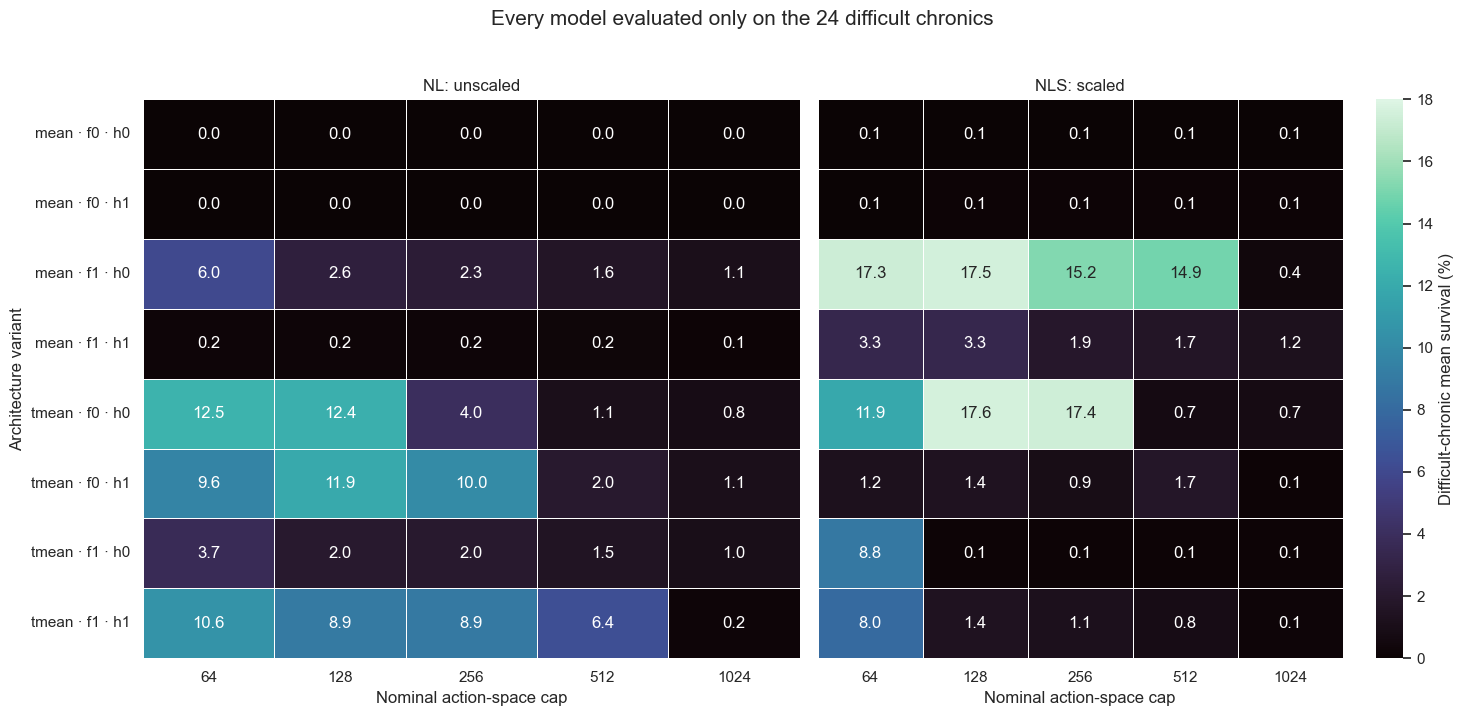

Best difficult-chronic mean: NLS · typed mean · f0 · a0h0 · cap 128 · 17.60% mean · 5.30% median · 3/24 rescues.
Best difficult-chronic median: NLS · mean · f1 · a0h0 · cap 64 · 7.40% median · 17.35% mean · 1/24 rescues.


In [16]:
difficult_action_space_summary = (
    difficult_model_metrics.groupby(["family", "action_size"], as_index=False)
    .agg(
        across_model_difficult_mean=("difficult_mean_survival_percent", "mean"),
        across_model_difficult_median=("difficult_median_survival_percent", "mean"),
        best_difficult_mean=("difficult_mean_survival_percent", "max"),
        mean_win_rate=("difficult_win_rate", "mean"),
        mean_rescue_rate=("difficult_rescue_rate", "mean"),
    )
)

difficult_heatmap_data = difficult_model_metrics.copy()
difficult_heatmap_data["variant"] = (
    difficult_heatmap_data["pool"] + " · f"
    + difficult_heatmap_data["features"].astype(str) + " · h"
    + difficult_heatmap_data["head"].astype(str)
)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
for axis, family in zip(axes, FAMILY_ORDER):
    matrix = (
        difficult_heatmap_data.loc[difficult_heatmap_data["family"].eq(family)]
        .pivot(
            index="variant", columns="action_size",
            values="difficult_mean_survival_percent"
        )
        .reindex(index=variant_order, columns=ACTION_ORDER)
    )
    sns.heatmap(
        matrix, annot=True, fmt=".1f", cmap="mako", vmin=0, vmax=18,
        linewidths=0.5, cbar=axis is axes[-1], ax=axis,
        cbar_kws={"label": "Difficult-chronic mean survival (%)"},
    )
    axis.set_title(f"{family}: {'scaled' if family == 'NLS' else 'unscaled'}")
    axis.set_xlabel("Nominal action-space cap")
    axis.set_ylabel("Architecture variant" if axis is axes[0] else "")
fig.suptitle("Every model evaluated only on the 24 difficult chronics", y=1.02, fontsize=15)
fig.tight_layout()
save_figure(fig, "difficult_chronic_all_models_heatmap")
plt.show()

best_difficult_mean = difficult_model_metrics.iloc[0]
best_difficult_median = difficult_model_metrics.sort_values(
    ["difficult_median_survival_percent", "difficult_mean_survival_percent"],
    ascending=False,
).iloc[0]
print(
    f"Best difficult-chronic mean: {best_difficult_mean['model_label']} · "
    f"cap {best_difficult_mean['action_size']} · "
    f"{best_difficult_mean['difficult_mean_survival_percent']:.2f}% mean · "
    f"{best_difficult_mean['difficult_median_survival_percent']:.2f}% median · "
    f"{int(best_difficult_mean['difficult_rescues'])}/24 rescues."
)
print(
    f"Best difficult-chronic median: {best_difficult_median['model_label']} · "
    f"cap {best_difficult_median['action_size']} · "
    f"{best_difficult_median['difficult_median_survival_percent']:.2f}% median · "
    f"{best_difficult_median['difficult_mean_survival_percent']:.2f}% mean · "
    f"{int(best_difficult_median['difficult_rescues'])}/24 rescues."
)


## 8. Detailed paired analysis of the best overall model

The interval below bootstraps the 50 paired chronic-level differences
between the best model and do-nothing. It quantifies uncertainty over
this test set only; it does not include checkpoint or training-seed
uncertainty.


In [17]:
best_model = ranking.iloc[0]
best_episodes = episode_analysis.loc[
    episode_analysis["run_id"].eq(best_model["run_id"])
].copy()

paired_differences = best_episodes["delta_vs_do_nothing_pp"].to_numpy()
paired_ci_low, paired_ci_high = bootstrap_mean_ci(
    paired_differences, seed=RNG_SEED + 100
)
best_cohort = (
    best_episodes.groupby("cohort", as_index=False)
    .agg(
        episodes=("episode", "size"),
        model_mean_survival=("survival", "mean"),
        do_nothing_mean_survival=("do_nothing_survival", "mean"),
        delta_pp=("delta_vs_do_nothing_pp", "mean"),
        model_full_survival_rate=("model_full_survival", "mean"),
        improved_rate=("improved_vs_do_nothing", "mean"),
        worse_rate=("worse_than_do_nothing", "mean"),
        intervention_rate=("policy_intervention_rate", "mean"),
    )
    .set_index("cohort")
    .reindex(COHORT_ORDER)
)
display(best_cohort.style.format({
    "model_mean_survival": "{:.2%}",
    "do_nothing_mean_survival": "{:.2%}",
    "delta_pp": "{:+.2f} pp",
    "model_full_survival_rate": "{:.1%}",
    "improved_rate": "{:.1%}",
    "worse_rate": "{:.1%}",
    "intervention_rate": "{:.2%}",
}))
print("Best model:", best_model["model_label"], "at cap", best_model["action_size"])
print(
    f"Overall: {best_model['mean_survival_percent']:.2f}% vs "
    f"{do_nothing_overall_percent:.2f}% for do-nothing "
    f"({best_model['delta_vs_do_nothing_pp']:+.2f} pp; "
    f"paired chronic bootstrap 95% interval "
    f"[{paired_ci_low:+.2f}, {paired_ci_high:+.2f}] pp)."
)


,episodes,model_mean_survival,do_nothing_mean_survival,delta_pp,model_full_survival_rate,improved_rate,worse_rate,intervention_rate
cohort,,,,,,,,
Do-nothing < 100%,24,17.43%,8.34%,+9.09 pp,12.5%,25.0%,58.3%,12.15%
Do-nothing = 100%,26,98.81%,100.00%,-1.19 pp,96.2%,0.0%,3.8%,24.59%


Best model: NLS · typed mean · f0 · a0h0 at cap 256
Overall: 59.75% vs 56.00% for do-nothing (+3.75 pp; paired chronic bootstrap 95% interval [-1.59, +10.42] pp).


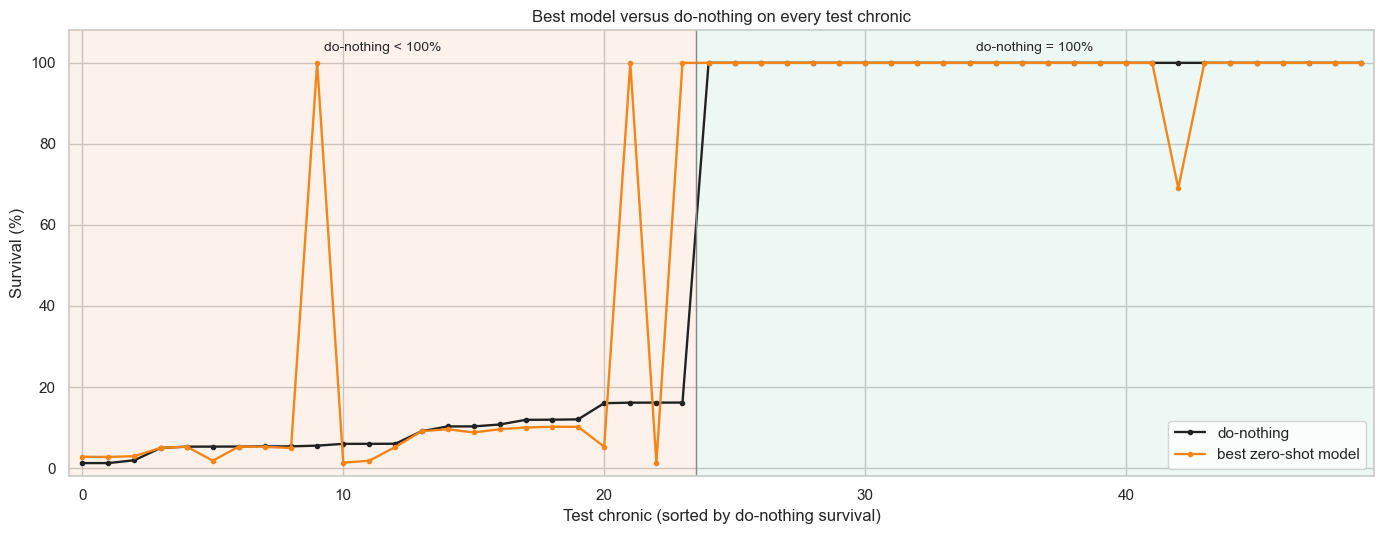

In [18]:
chronic_comparison_best_model = best_episodes[[
    "episode", "chronic_name", "chronic_fingerprint", "cohort",
    "steps", "max_steps", "survival", "do_nothing_steps",
    "do_nothing_survival", "delta_vs_do_nothing_pp",
    "model_full_survival", "policy_intervention_rate"
]].sort_values(["do_nothing_survival", "chronic_name"]).reset_index(drop=True)

fig, axis = plt.subplots(figsize=(14, 5.5))
x = np.arange(len(chronic_comparison_best_model))
axis.plot(
    x, chronic_comparison_best_model["do_nothing_survival"] * 100,
    color="#222222", marker="o", markersize=3, linewidth=1.7,
    label="do-nothing",
)
axis.plot(
    x, chronic_comparison_best_model["survival"] * 100,
    color=FAMILY_COLORS[best_model["family"]], marker="o", markersize=3,
    linewidth=1.7, label="best zero-shot model",
)
hard_count = int((~chronic_comparison_best_model["cohort"].eq("Do-nothing = 100%")).sum())
axis.axvspan(-0.5, hard_count - 0.5, color=COHORT_COLORS["Do-nothing < 100%"], alpha=0.08)
axis.axvspan(hard_count - 0.5, len(x) - 0.5, color=COHORT_COLORS["Do-nothing = 100%"], alpha=0.08)
axis.axvline(hard_count - 0.5, color="#888888", linewidth=1)
axis.text((hard_count - 1) / 2, 103, "do-nothing < 100%", ha="center", fontsize=10)
axis.text((hard_count + len(x) - 1) / 2, 103, "do-nothing = 100%", ha="center", fontsize=10)
axis.set_xlim(-0.5, len(x) - 0.5)
axis.set_ylim(-2, 108)
axis.set_xlabel("Test chronic (sorted by do-nothing survival)")
axis.set_ylabel("Survival (%)")
axis.set_title("Best model versus do-nothing on every test chronic")
axis.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "best_model_chronic_comparison")
plt.show()


## 9. Intervention behavior

This is diagnostic rather than causal. It checks whether poor
zero-shot transfer coincides with excessive non-idle decisions and
reports the association separately from survival rankings.


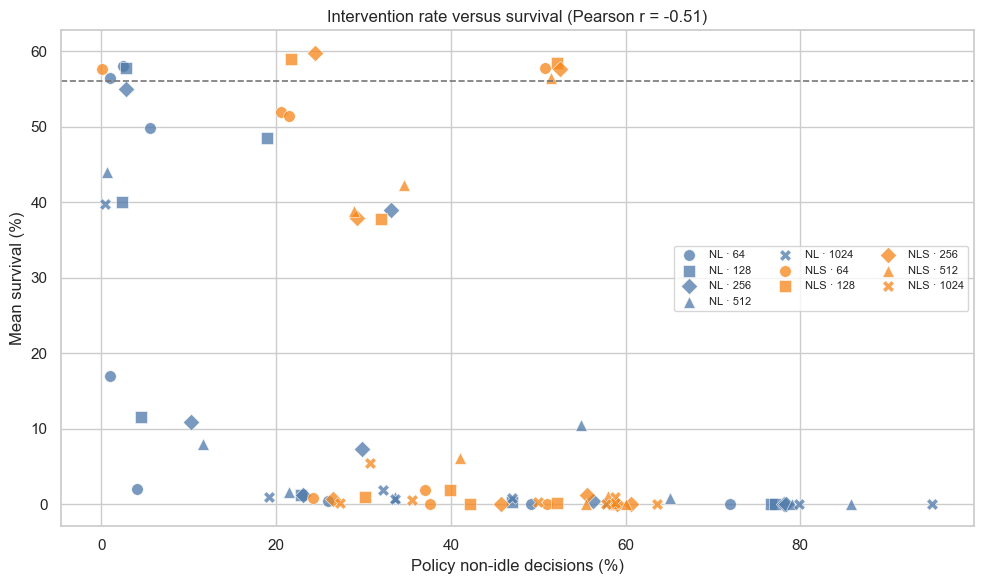

In [19]:
intervention_correlation = ranking[[
    "mean_survival_percent", "policy_intervention_percent"
]].corr().iloc[0, 1]

fig, axis = plt.subplots(figsize=(10, 6))
for (family, size), subset in ranking.groupby(["family", "action_size"]):
    axis.scatter(
        subset["policy_intervention_percent"], subset["mean_survival_percent"],
        color=FAMILY_COLORS[family], marker=marker_by_size[size],
        s=70, alpha=0.75, edgecolor="white", linewidth=0.5,
        label=f"{family} · {size}",
    )
axis.axhline(do_nothing_overall_percent, color="#777777", linestyle="--", linewidth=1.2)
axis.set_xlabel("Policy non-idle decisions (%)")
axis.set_ylabel("Mean survival (%)")
axis.set_title(f"Intervention rate versus survival (Pearson r = {intervention_correlation:.2f})")
axis.legend(ncol=3, fontsize=8)
fig.tight_layout()
save_figure(fig, "intervention_rate_vs_survival")
plt.show()


## 10. Data-driven conclusions

This cell is generated from the tables above so that rerunning the
notebook after replacing evaluations cannot leave stale prose.


In [20]:
robust_action_size = int(
    action_space_summary.loc[action_space_summary["across_model_mean"].idxmax(), "action_size"]
)
peak_action_size = int(best_model["action_size"])
best_nl = ranking.loc[ranking["family"].eq("NL")].iloc[0]
best_nls = ranking.loc[ranking["family"].eq("NLS")].iloc[0]

factor_lookup = factor_effect_summary.set_index("factor")
typed_effect = factor_lookup.loc["Typed mean (tmean − mean)"]
scaling_effect = factor_lookup.loc["Physical scaling (NLS − NL)"]
feature_effect = factor_lookup.loc["Candidate features (f1 − f0)"]
head_effect = factor_lookup.loc["Separate do-nothing head (h1 − h0)"]

hard = best_cohort.loc["Do-nothing < 100%"]
easy = best_cohort.loc["Do-nothing = 100%"]
hard_rescues = int(round(hard["model_full_survival_rate"] * hard["episodes"]))
easy_preserved = int(round(easy["model_full_survival_rate"] * easy["episodes"]))
action64 = action_space_summary.set_index("action_size").loc[64]
action1024 = action_space_summary.set_index("action_size").loc[1024]
best_overall_difficult = (
    difficult_model_metrics.set_index("run_id").loc[best_model["run_id"]]
)
best_overall_nonrescue_baseline = (
    best_overall_difficult["difficult_nonrescue_mean_survival_percent"]
    - best_overall_difficult["difficult_nonrescue_mean_delta_pp"]
)

conclusions = f'''
### Main answer

- **Best individual model:** `{best_model['model_label']}` with nominal
  cap **{peak_action_size}**, reaching **{best_model['mean_survival_percent']:.2f}%**
  mean survival. Do-nothing reaches **{do_nothing_overall_percent:.2f}%**,
  so the paired mean difference is **{best_model['delta_vs_do_nothing_pp']:+.2f} pp**
  (50-chronic bootstrap interval **[{paired_ci_low:+.2f}, {paired_ci_high:+.2f}] pp**).

- **Best robust action cap:** **{robust_action_size}**. Cap 64 has the
  highest mean across the 16 matched architectures
  (**{action64['across_model_mean']:.2f}%**) and wins for
  **{int(action64['config_wins'])}/16** variants. The best single result,
  however, is at cap {peak_action_size}; therefore “best cap” depends on
  whether the selection criterion is robustness or peak performance.
  Cap 1024 is clearly unfavorable here: its across-model mean falls to
  **{action1024['across_model_mean']:.2f}%** and it wins no matched variant.

- **Scaled versus unscaled:** NLS has a higher overall marginal mean
  (**{ranking.loc[ranking.family.eq('NLS'), 'mean_survival_percent'].mean():.2f}%**
  vs **{ranking.loc[ranking.family.eq('NL'), 'mean_survival_percent'].mean():.2f}%**),
  and its best model reaches **{best_nls['mean_survival_percent']:.2f}%**
  versus **{best_nl['mean_survival_percent']:.2f}%** for NL. But the
  matched scaling effect is only **{scaling_effect['median_effect_pp']:+.2f} pp**
  at the median and wins **{scaling_effect['win_rate']:.1%}** of pairs:
  scaling is beneficial in some strong interactions, not uniformly.

- **Architecture variations:** typed mean is the clearest positive
  factor (**{typed_effect['mean_effect_pp']:+.2f} pp** matched mean,
  **{typed_effect['win_rate']:.1%}** wins). Candidate features are much
  less stable (**{feature_effect['mean_effect_pp']:+.2f} pp**,
  **{feature_effect['win_rate']:.1%}** wins). The separate do-nothing
  head has no consistent benefit (**{head_effect['mean_effect_pp']:+.2f} pp**,
  **{head_effect['win_rate']:.1%}** wins). Large min/max effects in the
  factor table show strong interactions, so none of these should be
  interpreted as a universal causal rule from one seed.

### What happens on do-nothing-easy and do-nothing-hard chronics?

- On the **24 hard chronics** where do-nothing fails, the best model
  improves mean survival from **{hard['do_nothing_mean_survival']:.2%}**
  to **{hard['model_mean_survival']:.2%}**
  (**{hard['delta_pp']:+.2f} pp**) and fully rescues
  **{hard_rescues}/24** chronics. However, its difficult-chronic median
  is only **{best_overall_difficult['difficult_median_survival_percent']:.2f}%**
  versus a do-nothing median of
  **{do_nothing_cohorts.loc['Do-nothing < 100%', 'median']:.2f}%**.

- Those three rescues dominate the mean. On the other
  **{int(best_overall_difficult['difficult_nonrescue_episodes'])}** hard
  chronics, the model averages
  **{best_overall_difficult['difficult_nonrescue_mean_survival_percent']:.2f}%**
  versus **{best_overall_nonrescue_baseline:.2f}%** for do-nothing
  (**{best_overall_difficult['difficult_nonrescue_mean_delta_pp']:+.2f} pp**).
  It is therefore a selective-rescue policy, not a generally robust
  early-failure controller.

- **Best difficult-chronic mean:** `{best_difficult_mean['model_label']}`
  at cap **{int(best_difficult_mean['action_size'])}** with
  **{best_difficult_mean['difficult_mean_survival_percent']:.2f}%**.
  **Best difficult-chronic median:** `{best_difficult_median['model_label']}`
  at cap **{int(best_difficult_median['action_size'])}** with
  **{best_difficult_median['difficult_median_survival_percent']:.2f}%**.
  The latter is the stronger choice when typical hard-chronic behavior
  matters more than a few complete rescues.

- On the **26 easy chronics** where do-nothing reaches 100%, the same
  model averages **{easy['model_mean_survival']:.2%}** and preserves
  full survival on **{easy_preserved}/26**. Its cost on this cohort is
  **{easy['delta_pp']:+.2f} pp**: it damages one otherwise-safe chronic,
  but only slightly lowers the cohort mean.

- The aggregate gain comes from a small number of large successful
  rescues while the policy largely preserves easy chronics. The paired
  bootstrap interval still crosses zero, so this behavior is promising
  but brittle rather than evidence of systematic hard-chronic control.

- Across all 80 evaluations, intervention rate and survival have a
  descriptive correlation of **r = {intervention_correlation:.2f}**.
  This suggests over-intervention is a useful failure diagnostic in
  zero-shot transfer, but it is not proof that intervention frequency
  itself causes the failures.
'''
display(Markdown(conclusions))



### Main answer

- **Best individual model:** `NLS · typed mean · f0 · a0h0` with nominal
  cap **256**, reaching **59.75%**
  mean survival. Do-nothing reaches **56.00%**,
  so the paired mean difference is **+3.75 pp**
  (50-chronic bootstrap interval **[-1.59, +10.42] pp**).

- **Best robust action cap:** **64**. Cap 64 has the
  highest mean across the 16 matched architectures
  (**25.33%**) and wins for
  **9/16** variants. The best single result,
  however, is at cap 256; therefore “best cap” depends on
  whether the selection criterion is robustness or peak performance.
  Cap 1024 is clearly unfavorable here: its across-model mean falls to
  **3.24%** and it wins no matched variant.

- **Scaled versus unscaled:** NLS has a higher overall marginal mean
  (**17.24%**
  vs **14.17%**),
  and its best model reaches **59.75%**
  versus **58.00%** for NL. But the
  matched scaling effect is only **+0.02 pp**
  at the median and wins **65.0%** of pairs:
  scaling is beneficial in some strong interactions, not uniformly.

- **Architecture variations:** typed mean is the clearest positive
  factor (**+16.97 pp** matched mean,
  **72.5%** wins). Candidate features are much
  less stable (**+1.81 pp**,
  **62.5%** wins). The separate do-nothing
  head has no consistent benefit (**-1.92 pp**,
  **50.0%** wins). Large min/max effects in the
  factor table show strong interactions, so none of these should be
  interpreted as a universal causal rule from one seed.

### What happens on do-nothing-easy and do-nothing-hard chronics?

- On the **24 hard chronics** where do-nothing fails, the best model
  improves mean survival from **8.34%**
  to **17.43%**
  (**+9.09 pp**) and fully rescues
  **3/24** chronics. However, its difficult-chronic median
  is only **5.27%**
  versus a do-nothing median of
  **5.99%**.

- Those three rescues dominate the mean. On the other
  **21** hard
  chronics, the model averages
  **5.64%**
  versus **7.73%** for do-nothing
  (**-2.09 pp**).
  It is therefore a selective-rescue policy, not a generally robust
  early-failure controller.

- **Best difficult-chronic mean:** `NLS · typed mean · f0 · a0h0`
  at cap **128** with
  **17.60%**.
  **Best difficult-chronic median:** `NLS · mean · f1 · a0h0`
  at cap **64** with
  **7.40%**.
  The latter is the stronger choice when typical hard-chronic behavior
  matters more than a few complete rescues.

- On the **26 easy chronics** where do-nothing reaches 100%, the same
  model averages **98.81%** and preserves
  full survival on **25/26**. Its cost on this cohort is
  **-1.19 pp**: it damages one otherwise-safe chronic,
  but only slightly lowers the cohort mean.

- The aggregate gain comes from a small number of large successful
  rescues while the policy largely preserves easy chronics. The paired
  bootstrap interval still crosses zero, so this behavior is promising
  but brittle rather than evidence of systematic hard-chronic control.

- Across all 80 evaluations, intervention rate and survival have a
  descriptive correlation of **r = -0.51**.
  This suggests over-intervention is a useful failure diagnostic in
  zero-shot transfer, but it is not proof that intervention frequency
  itself causes the failures.


## 11. Export analysis-ready tables

The core DataFrames remain available in memory and are also written as
CSV/JSON artifacts for report tables or follow-up analyses.


In [21]:
exports = {
    "run_ranking.csv": ranking,
    "action_space_catalog.csv": action_space_catalog,
    "action_space_summary.csv": action_space_summary,
    "action_size_vs_64.csv": action_size_vs_64,
    "matched_factor_effects.csv": matched_factor_effects,
    "factor_effect_summary.csv": factor_effect_summary,
    "factor_effect_by_action_size.csv": factor_effect_by_size,
    "do_nothing_stratified_by_model.csv": cohort_wide,
    "do_nothing_stratified_by_family_size.csv": cohort_by_family_size,
    "difficult_chronic_model_metrics.csv": difficult_model_metrics,
    "difficult_chronic_action_space_summary.csv": difficult_action_space_summary,
    "episode_level_joined.csv": episode_analysis,
    "best_model_chronic_comparison.csv": chronic_comparison_best_model,
}
for filename, frame in exports.items():
    frame.to_csv(EXPORT_DIR / filename, index=False)

conclusion_payload = {
    "best_model": {
        "run_id": best_model["run_id"],
        "model_label": best_model["model_label"],
        "action_size": int(best_model["action_size"]),
        "mean_survival_percent": float(best_model["mean_survival_percent"]),
        "delta_vs_do_nothing_pp": float(best_model["delta_vs_do_nothing_pp"]),
        "paired_bootstrap_95pct_pp": [float(paired_ci_low), float(paired_ci_high)],
    },
    "do_nothing_overall_percent": float(do_nothing_overall_percent),
    "robust_action_size": robust_action_size,
    "best_difficult_mean": {
        "run_id": best_difficult_mean["run_id"],
        "model_label": best_difficult_mean["model_label"],
        "action_size": int(best_difficult_mean["action_size"]),
        "mean_survival_percent": float(
            best_difficult_mean["difficult_mean_survival_percent"]
        ),
        "median_survival_percent": float(
            best_difficult_mean["difficult_median_survival_percent"]
        ),
    },
    "best_difficult_median": {
        "run_id": best_difficult_median["run_id"],
        "model_label": best_difficult_median["model_label"],
        "action_size": int(best_difficult_median["action_size"]),
        "mean_survival_percent": float(
            best_difficult_median["difficult_mean_survival_percent"]
        ),
        "median_survival_percent": float(
            best_difficult_median["difficult_median_survival_percent"]
        ),
    },
    "intervention_survival_correlation": float(intervention_correlation),
}
with (EXPORT_DIR / "conclusions.json").open("w", encoding="utf-8") as handle:
    json.dump(conclusion_payload, handle, indent=2)

export_index = pd.DataFrame({
    "artifact": [*exports.keys(), "conclusions.json"],
    "path": [str(EXPORT_DIR / name) for name in [*exports.keys(), "conclusions.json"]],
})
display(export_index)


,artifact,path
0,run_ranking.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
1,action_space_catalog.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
2,action_space_summary.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
3,action_size_vs_64.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
4,matched_factor_effects.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
5,factor_effect_summary.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
6,factor_effect_by_action_size.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
7,do_nothing_stratified_by_model.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
8,do_nothing_stratified_by_family_size.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...
9,difficult_chronic_model_metrics.csv,/Users/corentinplumet/Documents/RL_Marl2grid/T...


### Interpretation limits

- All comparisons use the same 50 WCCI test chronics and deterministic
  evaluation, which makes episode matching strong.
- There is only one training seed and one selected checkpoint per
  architecture. Very large interactions may reflect checkpoint
  selection as well as architecture.
- The reduced spaces are nested by top-ranked candidate actions, but
  the nominal cap differs from the actual per-agent count when an
  agent's original candidate set is smaller.
- No WCCI fine-tuning is performed: these conclusions describe
  zero-shot transfer, not expected performance after adaptation.
